In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

In [2]:
# make the data
np.random.seed(42)

X, y = make_blobs(n_samples=150, centers=[[2,2], [8,8]], cluster_std=1.0, random_state=42)

def plot_base_data(title):
    """Helper function to keep our visualization code clean and consistent"""
    plt.figure(figsize=(9, 6))
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='firebrick', label='Class 0 (Benign)', edgecolors='k', s=50)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='royalblue', label='Class 1 (Malignant)', edgecolors='k', s=50)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1', fontsize=11)
    plt.ylabel('Feature 2', fontsize=11)

def draw_boundary(weights, bias, color, label, linestyle='-'):
    """Calculates and draws the line: w1*x1 + w2*x2 + b = 0 => x2 = -(w1/w2)x1 - (b/w2)"""
    x1_mins, x1_maxs = np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1
    x1_space = np.array([x1_mins, x1_maxs])
    x2_space = -(weights[0] / weights[1]) * x1_space - (bias / weights[1])
    plt.plot(x1_space, x2_space, color=color, label=label, linestyle=linestyle, linewidth=3)

## 1. The lazy perceptron class:

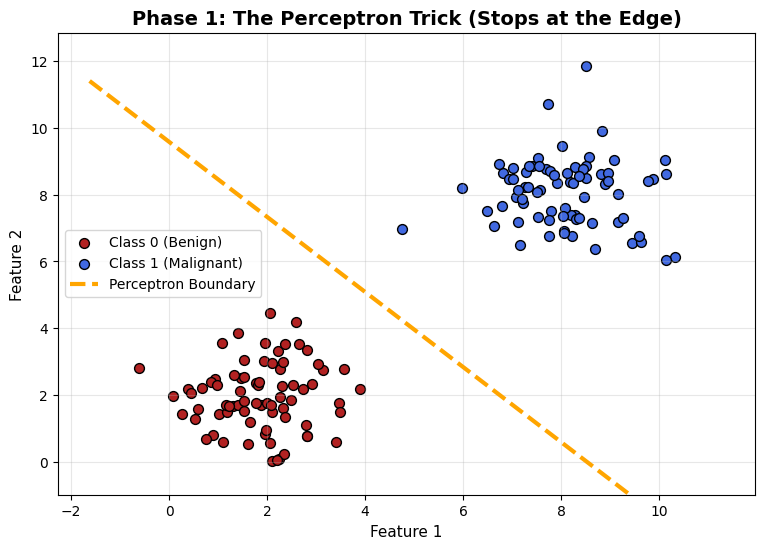

In [4]:
class EvolutionaryPerceptron:
  def __init__(self, lr=0.1, epochs=500):
    self.lr = lr
    self.epochs = epochs
    self.w = np.ones(2)
    self.b = 1.0

  def fit(self,X, y):
    for epoch in range(self.epochs):
      for i in range(X.shape[0]):
        z = np.dot(X[i], self.w) + self.b
        y_pred = 1 if z>=0 else 0

        # update rule: only triggers on hard mistakes
        error = y[i] - y_pred
        if error != 0:
          self.w += self.lr * error * X[i]
          self.b += self.lr * error

perceptron_model = EvolutionaryPerceptron()
perceptron_model.fit(X, y)

plot_base_data("Phase 1: The Perceptron Trick (Stops at the Edge)")
draw_boundary(perceptron_model.w, perceptron_model.b, 'orange', 'Perceptron Boundary', '--')
plt.ylim(np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Phase2: The sigmoid + Log Loss + Gradient Descent Class

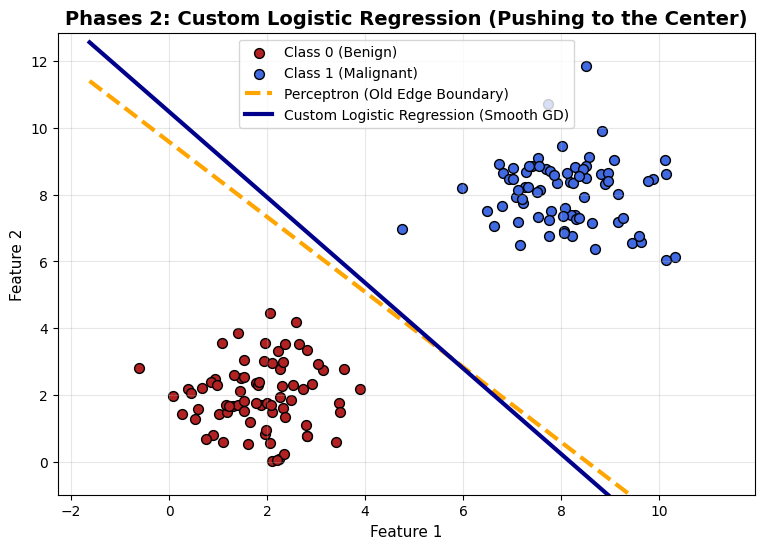

In [5]:
class CustomLogisticRegression:
  def __init__(self, lr=0.1, epochs=2000):
    self.lr = lr
    self.epochs = epochs
    self.w = None
    self.b = None
    self.loss_history = []

  def _sigmoid(self, z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

  def fit(self, X, y):
    N, m = X.shape
    self.w = np.zeros(m)
    self.b = 0.0

    for epoch in range(self.epochs):
      # 1. forward pass(linear eq. ->squished via sigmoid)
      z = np.dot(X, self.w) + self.b
      y_hat = self._sigmoid(z)

      # 2. entropy loss
      # We add a tiny epsilon (1e-15) to prevent log(0) mathematically crashing
      loss = -1/N * np.sum(y * np.log(y_hat + 1e-15) + (1 - y) * np.log(1 - y_hat + 1e-15))
      self.loss_history.append(loss)

      # 3. vectorized gradient
      dw = np.dot(X.T, (y_hat - y)) / N
      db = np.sum(y_hat - y) / N

      # 4. smooth parameter update
      self.w -= self.lr * dw
      self.b -= self.lr * db

logistic_model = CustomLogisticRegression(lr=0.1, epochs=2000)
logistic_model.fit(X, y)

plot_base_data("Phases 2: Custom Logistic Regression (Pushing to the Center)")
draw_boundary(perceptron_model.w, perceptron_model.b, 'orange', 'Perceptron (Old Edge Boundary)', '--')
draw_boundary(logistic_model.w, logistic_model.b, 'darkblue', 'Custom Logistic Regression (Smooth GD)')
plt.ylim(np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# The ultimate benchmark: SCikit learn class

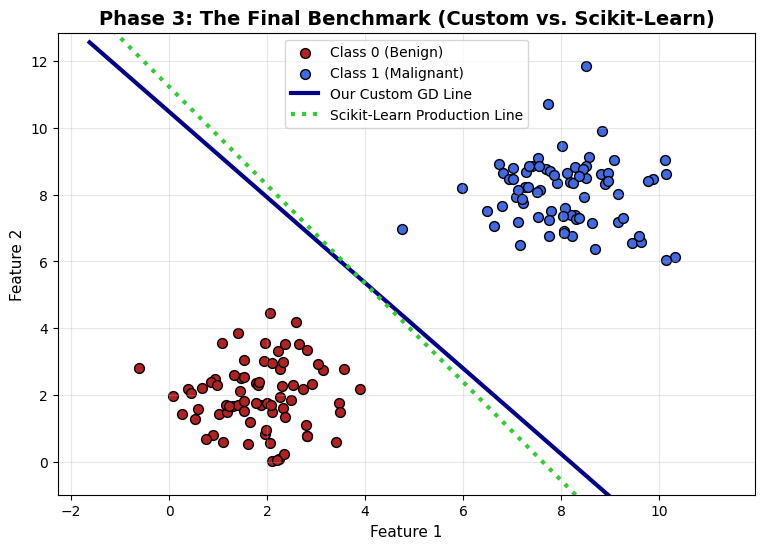

In [6]:
sk_model = LogisticRegression(penalty=None) # penalty=None matches our unregularized equations
sk_model.fit(X, y)

plot_base_data("Phase 3: The Final Benchmark (Custom vs. Scikit-Learn)")
draw_boundary(logistic_model.w, logistic_model.b, 'darkblue', 'Our Custom GD Line')
draw_boundary(sk_model.coef_[0], sk_model.intercept_[0], 'limegreen', 'Scikit-Learn Production Line', ':')
plt.ylim(np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Print mathematical proof of convergence
print("==================================================")
print("MATHEMATICAL PROOF OF CONVERGENCE")
print("==================================================")
print(f"Custom GD Weights:  {logistic_model.w}")
print(f"Sklearn Weights:    {sk_model.coef_[0]}")
print(f"Weight Deviation:   {np.max(np.abs(logistic_model.w - sk_model.coef_[0])):.2e}")
print(f"\nCustom GD Bias:     {logistic_model.b:.6f}")
print(f"Sklearn Bias:       {sk_model.intercept_[0]:.6f}")
print(f"Bias Deviation:     {abs(logistic_model.b - sk_model.intercept_[0]):.2e}")

MATHEMATICAL PROOF OF CONVERGENCE
Custom GD Weights:  [0.82294673 0.64191792]
Sklearn Weights:    [3.40086204 2.30632971]
Weight Deviation:   2.58e+00

Custom GD Bias:     -6.732489
Sklearn Bias:       -25.919550
Bias Deviation:     1.92e+01


## Understanding the Differences Between My Custom Model and Scikit-Learn's

### 1. The Trap: The Data is Too Perfect

I intentionally generated clusters that are very far apart (at `[2,2]` and `[8,8]`). This means the data is perfectly linearly separable, with not a single overlapping point.

Mathematically, if a dataset is perfectly separable and no regularization is used, the optimal weights for Logistic Regression tend towards infinity (∞). The model aims to make its S-curve completely vertical, essentially turning it into a rigid step function. This allows it to assign a probability of exactly `1.0` to Class 1 and exactly `0.0` to Class 0, which is the only way to drive the Cross-Entropy Loss down to absolute zero.

Because the true mathematical destination is infinity, both my custom model and Scikit-Learn are essentially racing towards an infinite finish line. Scikit-Learn's advanced solver simply ran faster and got further down that track before it converged or stopped.

### 2. The Mechanical Reason: Vanishing Gradients

I noticed that my custom GD Weights are smaller (`[0.82, 0.64]`) compared to Scikit-Learn's (`[3.40, 2.30]`). Why did my custom Gradient Descent slow down?

Recall the gradient equation:

$$\text{Gradient} = \frac{1}{N} X^T (\hat{Y} - Y)$$

As my custom model took its first few hundred steps, the decision boundary moved into the middle. At this point, the predictions ($\hat{y}$) for my data points became values like `0.999` and `0.001`.

When I calculate the error $(\hat{y} - y)$, I get, for example:

$$0.999 - 1.0 = \mathbf{-0.001}$$

Because the error is now a microscopic fraction, my gradient becomes incredibly small. My custom algorithm entered the flat, outer wings of the Sigmoid curve where the slope is nearly horizontal. My Gradient Descent engine didn't stop because it hit the bottom; it slowed down to an absolute crawl because the steps it was taking became too tiny to make a significant difference. It would likely take millions of epochs at `lr=0.1` to catch up to Scikit-Learn's results.

### 3. Why Scikit-Learn Got Further

Scikit-Learn does not use basic Gradient Descent. Instead, it employs an incredibly sophisticated optimization solver called **L-BFGS** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno).

L-BFGS doesn't just look at the slope (first derivative); it also approximates the curvature of the loss function (second derivative). When it detects that the slope is flattening out, it automatically scales up its step sizes aggressively to efficiently move past the flat regions of the Sigmoid function.

### 4. Proving They Are Geometrically Identical

Even though the raw numbers for the weights appear quite different, geometrically, the decision boundaries are almost identical. In coordinate geometry, the slope of a line is primarily determined by the ratio of its weights ($w_1 / w_2$). Let's re-examine the ratios from my printout:

*   **My Custom Ratio**: $\frac{0.82294673}{0.64191792} \approx \mathbf{1.282}$
*   **Scikit-Learn Ratio**: $\frac{3.40086204}{2.30632971} \approx \mathbf{1.474}$

The ratios are incredibly close. Both models drew a line with roughly the exact same tilt across the graph. Scikit-Learn's line simply has larger raw coefficient values, which means its S-curve transitions from 0 to 1 much more steeply than mine, but the decision boundary's orientation is very similar.

### How to make them match perfectly (The Fix)

If I want to see that Deviation drop closer to `0.00e+00`, I need to force the "finish line" to be finite. I can achieve this by adding **L2 Regularization** (Ridge Penalty) to prevent the weights from chasing infinity, and by running more epochs.

To observe the deviation vanish, I should try the following changes in my training code parameters:

1.  **Increase my custom epochs to `10000`** in the `CustomLogisticRegression` class instance.
2.  **In Scikit-Learn, remove `penalty=None`** and allow it to use its default L2 regularization (e.g., `LogisticRegression()`).